In [1]:
#stress prediction using gsr, hr, facial expression, body temperature

# Import necessary libraries
import pandas as pd
import requests
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_boston
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifierfa
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import mean_squared_error, accuracy_score


ImportError: 
`load_boston` has been removed from scikit-learn since version 1.2.

The Boston housing prices dataset has an ethical problem: as
investigated in [1], the authors of this dataset engineered a
non-invertible variable "B" assuming that racial self-segregation had a
positive impact on house prices [2]. Furthermore the goal of the
research that led to the creation of this dataset was to study the
impact of air quality but it did not give adequate demonstration of the
validity of this assumption.

The scikit-learn maintainers therefore strongly discourage the use of
this dataset unless the purpose of the code is to study and educate
about ethical issues in data science and machine learning.

In this special case, you can fetch the dataset from the original
source::

    import pandas as pd
    import numpy as np

    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
    data = np.hstack([raw_df.values[:

In [ ]:
#https://docs.google.com/spreadsheets/d/e/2PACX-1vSqvf-JYef0niymGLVvZKJ1EbQPs5b4WAA0mrVxGpYOh9N_B68iwyQFObHtzytJvKS0Xo6k1k3qUK-D/pub?output=csv
# google sheets link


In [ ]:
# loading my sheets into the model
google_sheets_url = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vSqvf-JYef0niymGLVvZKJ1EbQPs5b4WAA0mrVxGpYOh9N_B68iwyQFObHtzytJvKS0Xo6k1k3qUK-D/pub?output=csv'

# Fetch the data from the published Google Sheets using requests
response = requests.get(google_sheets_url)

# Read the data into a Pandas DataFrame
dframe = pd.read_csv(response.url)
dframe.head()


,gsr,b_temp,hr,f_ex,stress_level
0,6.8,98.6,73,Panic,3
1,5.9,98.6,79,Concerned,4
2,6.5,98.2,82,Concerned,4
3,6.7,98.2,80,Panic,4
4,6.8,98.6,83,Relaxed,2


In [ ]:
dframe.describe


<bound method NDFrame.describe of        gsr  b_temp  hr       f_ex  stress_level
0      6.8    98.6  73      Panic             3
1      5.9    98.6  79  Concerned             4
2      6.5    98.2  82  Concerned             4
3      6.7    98.2  80      Panic             4
4      6.8    98.6  83    Relaxed             2
...    ...     ...  ..        ...           ...
99995  7.0    98.6  74  Concerned             4
99996  5.8    98.4  82  Concerned             1
99997  5.9    98.6  78    Relaxed             2
99998  5.9    98.7  81    Relaxed             4
99999  6.5    98.7  78      Panic             4

[100000 rows x 5 columns]>

In [ ]:
dframe.info


<bound method DataFrame.info of        gsr  b_temp  hr       f_ex  stress_level
0      6.8    98.6  73      Panic             3
1      5.9    98.6  79  Concerned             4
2      6.5    98.2  82  Concerned             4
3      6.7    98.2  80      Panic             4
4      6.8    98.6  83    Relaxed             2
...    ...     ...  ..        ...           ...
99995  7.0    98.6  74  Concerned             4
99996  5.8    98.4  82  Concerned             1
99997  5.9    98.6  78    Relaxed             2
99998  5.9    98.7  81    Relaxed             4
99999  6.5    98.7  78      Panic             4

[100000 rows x 5 columns]>

In [ ]:
dframe.isnull().sum()


gsr             0
b_temp          0
hr              0
f_ex            0
stress_level    0
dtype: int64

In [ ]:
dframe['f_ex'].value_counts()


f_ex
Relaxed      27409
Concerned    24649
Anxious      24090
Panic        23852
Name: count, dtype: int64

In [ ]:
#Feature Engineeering -- f_ex
#On categorical data we apply "ONE HOT ENCODING" through pandas in-built get_dummies feature
f_ex = dframe['f_ex']
f_ex = pd.get_dummies(f_ex, drop_first=True)
f_ex.head()
#One Hot Coding on categorical data generates 1 less feature (uniqueset of binary string)


,Concerned,Panic,Relaxed
0,False,True,False
1,True,False,False
2,True,False,False
3,False,True,False
4,False,False,True


In [ ]:
dframe.head()


,gsr,b_temp,hr,f_ex,stress_level
0,6.8,98.6,73,Panic,3
1,5.9,98.6,79,Concerned,4
2,6.5,98.2,82,Concerned,4
3,6.7,98.2,80,Panic,4
4,6.8,98.6,83,Relaxed,2


In [ ]:
#Visualisation using catplots
dframe = dframe.sort_values('stress_level')
sns.catplot(y='stress_level', x='gsr', data = dframe.sort_values('stress_level') , kind='boxen' , height=10 , aspect=10)


NameError: name 'dframe' is not defined

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: 

OptionError: No such keys(s): 'mode.use_inf_as_null'

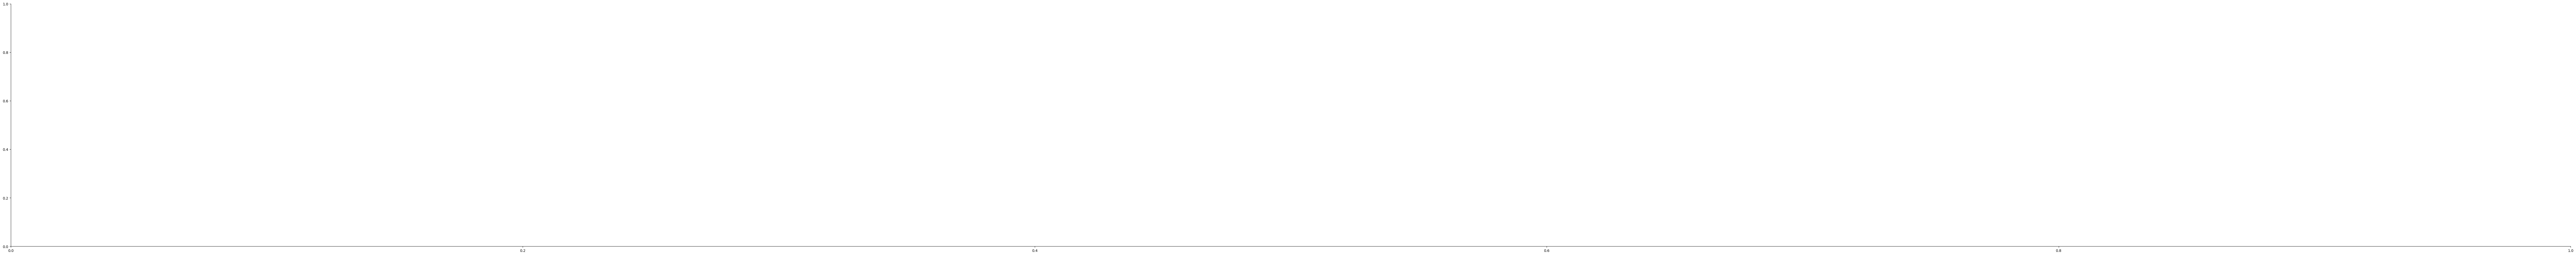

In [ ]:
#Visualisation using catplots
sns.catplot(y='stress_level', x='b_temp', data=dframe.sort_values(
    'stress_level', ascending=False), kind='boxen', height=10, aspect=10)


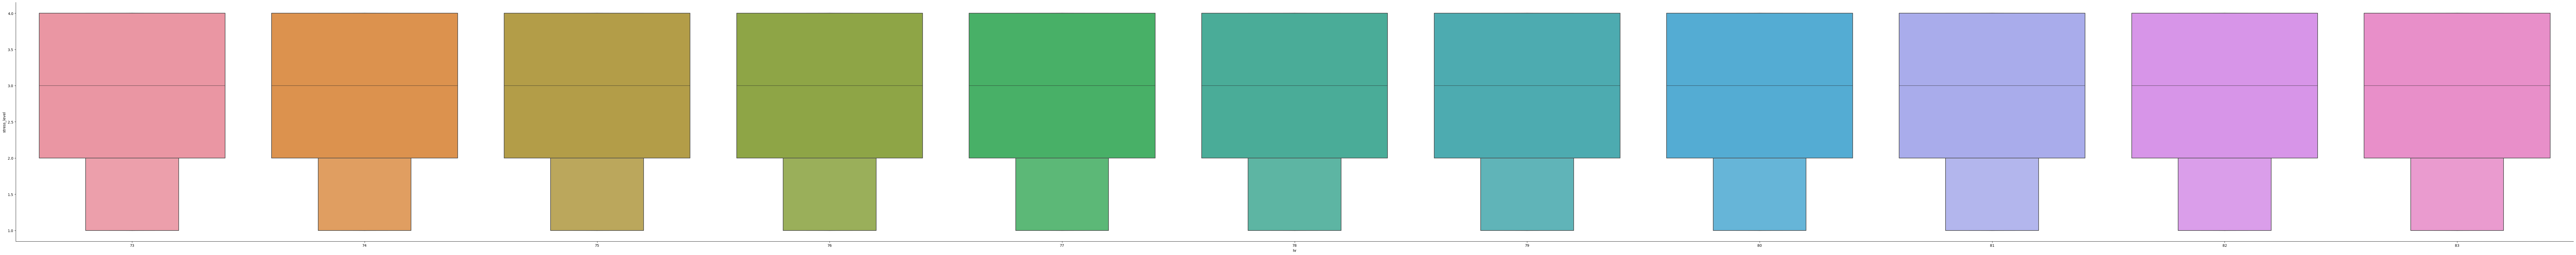

In [ ]:
#Visualisation using catplots
sns.catplot(y='stress_level', x='hr', data=dframe.sort_values(
    'stress_level', ascending=False), kind='boxen', height=10, aspect=10)


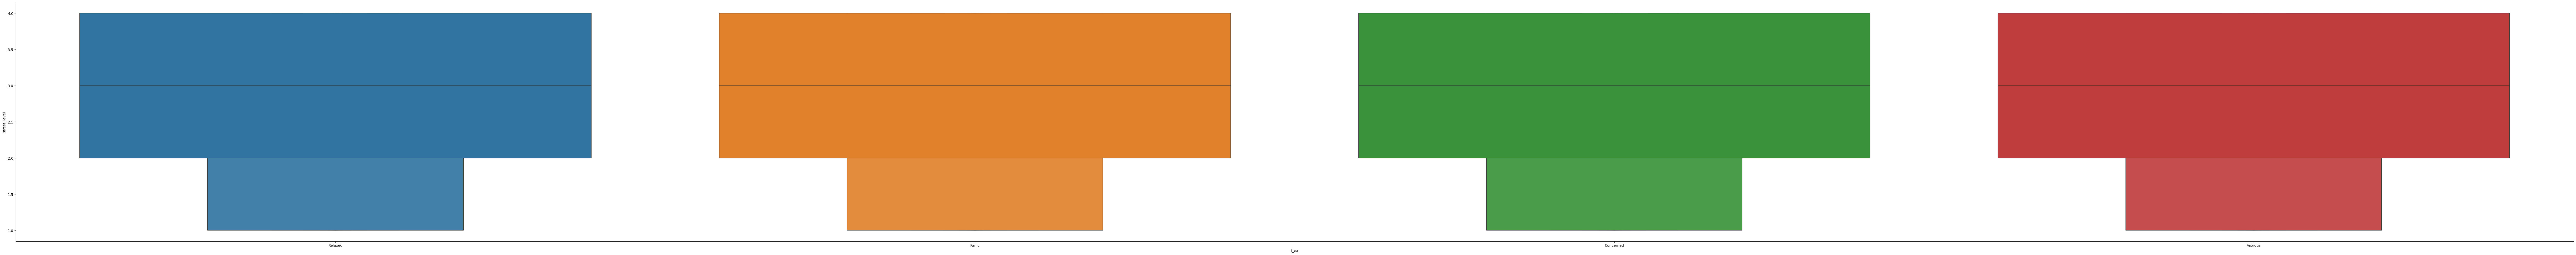

In [ ]:
#Visualisation using catplots
sns.catplot(y='stress_level', x='f_ex', data=dframe.sort_values(
    'stress_level', ascending=False), kind='boxen', height=10, aspect=10)


In [ ]:

# Calculate the correlation matrix
correlation_matrix = dframe.corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


ValueError: could not convert string to float: 'Concerned'